Shape: (25000, 35)
Missing: 0
Target Distribution:
 Churn
0    0.58572
1    0.41428
Name: proportion, dtype: float64
AUC: 0.6431444722920152
              precision    recall  f1-score   support

           0       0.67      0.64      0.65      2929
           1       0.52      0.56      0.54      2071

    accuracy                           0.61      5000
   macro avg       0.60      0.60      0.60      5000
weighted avg       0.61      0.61      0.61      5000


Best Threshold: 0.30000000000000004

Final Optimized Metrics
Recall: 0.9261226460647031
Precision: 0.44203733579165705
F1: 0.5984399375975039


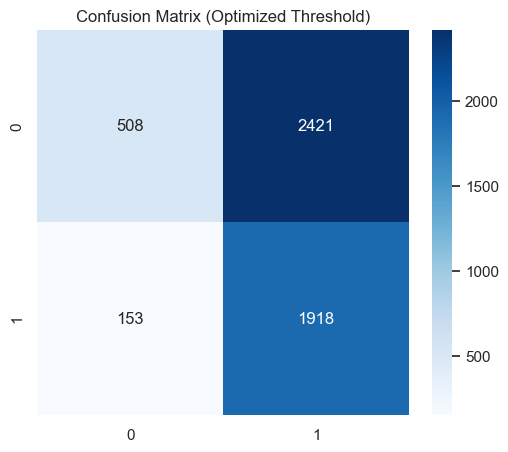

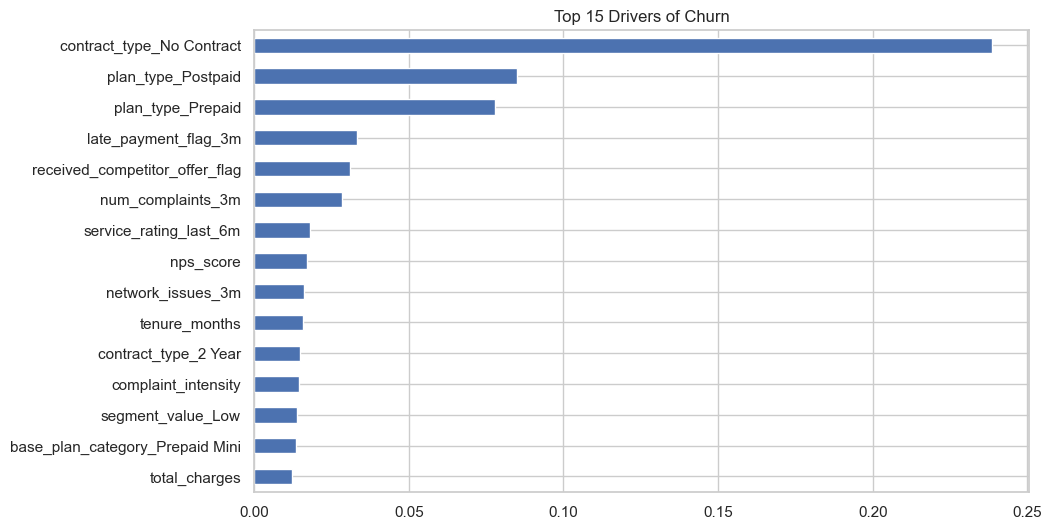


Model saved successfully.


In [1]:
# ==========================================================
# CONNECTTEL CHURN PREDICTION SYSTEM
# Production-Ready Pipeline
# ==========================================================

# ===============================
# 1️⃣ ENVIRONMENT SETUP
# ===============================

import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

RANDOM_STATE = 42
sns.set(style="whitegrid")

# ===============================
# 2️⃣ LOAD DATA
# ===============================

df = pd.read_csv("..//data/raw/telecom_churn.csv")

df.columns = df.columns.str.strip()
df.rename(columns={"is_churn": "Churn"}, inplace=True)

# Drop leakage columns
df.drop(columns=["customer_id"], inplace=True)

print("Shape:", df.shape)
print("Missing:", df.isnull().sum().sum())
print("Target Distribution:\n", df["Churn"].value_counts(normalize=True))

# ===============================
# 3️⃣ FEATURE ENGINEERING
# ===============================

# Tenure Buckets
df["tenure_bucket"] = pd.cut(
    df["tenure_months"],
    bins=[0,12,24,48,72,120],
    labels=["0-1yr","1-2yr","2-4yr","4-6yr","6yr+"]
)

# Bill Shock
df["bill_shock"] = np.where(
    df["monthly_charges"] > df["monthly_charges"].quantile(0.75),
    1, 0
)

# Complaint Intensity
df["complaint_intensity"] = (
    df["num_complaints_3m"] + df["num_complaints_12m"]
)

# Engagement Score
df["engagement_score"] = (
    df["app_logins_30d"] + df["selfcare_transactions_30d"]
)

# Payment Risk
df["payment_risk"] = np.where(
    df["avg_payment_delay_days"] > 5,
    1, 0
)

# ===============================
# 4️⃣ TRAIN TEST SPLIT
# ===============================

X = df.drop("Churn", axis=1)
y = df["Churn"]

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64","float64"]).columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

# ===============================
# 5️⃣ PREPROCESSING PIPELINE
# ===============================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# ===============================
# 6️⃣ MODEL (TUNED XGBOOST)
# ===============================

scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE
    ))
])

model.fit(X_train, y_train)

# ===============================
# 7️⃣ EVALUATION
# ===============================

probs = model.predict_proba(X_test)[:,1]
preds = model.predict(X_test)

print("AUC:", roc_auc_score(y_test, probs))
print(classification_report(y_test, preds))

# ===============================
# 8️⃣ THRESHOLD OPTIMIZATION
# ===============================

thresholds = np.arange(0.1, 0.9, 0.05)

best_threshold = 0
best_f1 = 0

for t in thresholds:
    custom_preds = (probs >= t).astype(int)
    f1 = f1_score(y_test, custom_preds)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("\nBest Threshold:", best_threshold)

final_preds = (probs >= best_threshold).astype(int)

print("\nFinal Optimized Metrics")
print("Recall:", recall_score(y_test, final_preds))
print("Precision:", precision_score(y_test, final_preds))
print("F1:", f1_score(y_test, final_preds))

# Confusion Matrix
cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Optimized Threshold)")
plt.show()

# ===============================
# 9️⃣ FEATURE IMPORTANCE
# ===============================

clf = model.named_steps["classifier"]
importances = clf.feature_importances_

ohe = model.named_steps["preprocessor"].named_transformers_["cat"]
encoded_features = ohe.get_feature_names_out(categorical_cols)

all_features = np.concatenate([numeric_cols, encoded_features])

feature_importance = pd.Series(importances, index=all_features)
top_features = feature_importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
top_features.sort_values().plot(kind="barh")
plt.title("Top 15 Drivers of Churn")
plt.show()

# ===============================
# 🔟 SAVE MODEL (API READY)
# ===============================

joblib.dump(model, "churn_model.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")
joblib.dump(best_threshold, "optimal_threshold.pkl")

print("\nModel saved successfully.")